# 比特币走势预测 - 完整检验步骤的 ARIMA 模型

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ======================== 1. 数据加载与预处理 ========================
file_path = r"D:\2026上学期\商业数据分析Python\结课作业\结课作业\final\bitcoin_btc.csv"
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# 筛选时间范围
start_date = '2014-09-17'
end_date = '2026-05-19'
df = df.loc[start_date:end_date]
print(f"数据时间范围：{df.index.min()} 至 {df.index.max()}")
print(f"原始数据行数：{len(df)}")

# 重采样为月度平均值
df_month = df.resample('M').mean()
df_month.rename(columns={'price': 'Price'}, inplace=True)
print(f"月度数据点数：{len(df_month)}")
print(df_month.head())

数据时间范围：2014-09-17 00:00:00 至 2026-05-19 00:00:00
原始数据行数：4250
月度数据点数：141
                 Price
date                  
2014-09-30  407.182429
2014-10-31  364.148871
2014-11-30  366.099800
2014-12-31  341.267871
2015-01-31  248.782548


# 2.图检验 

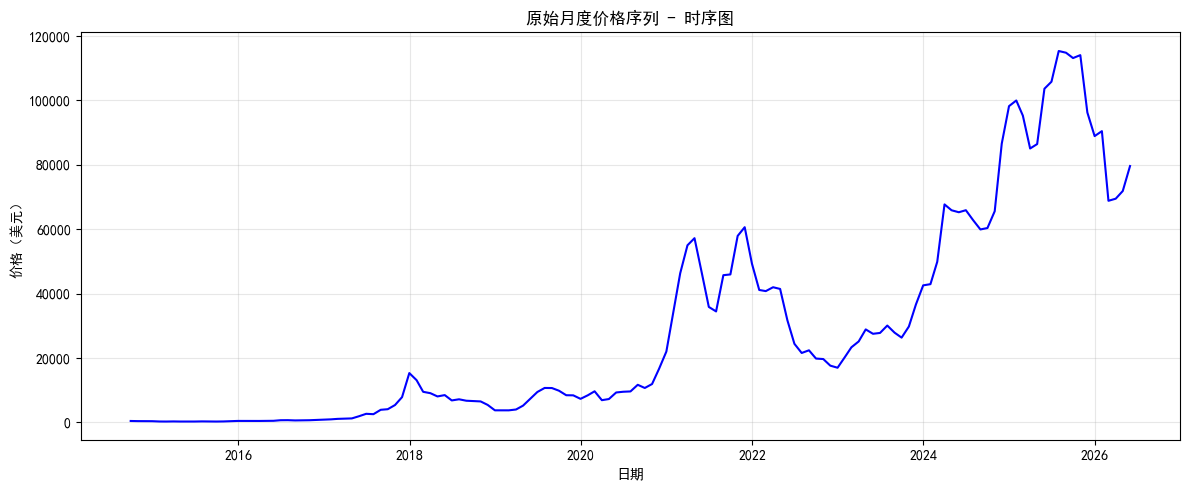

<Figure size 1200x500 with 0 Axes>

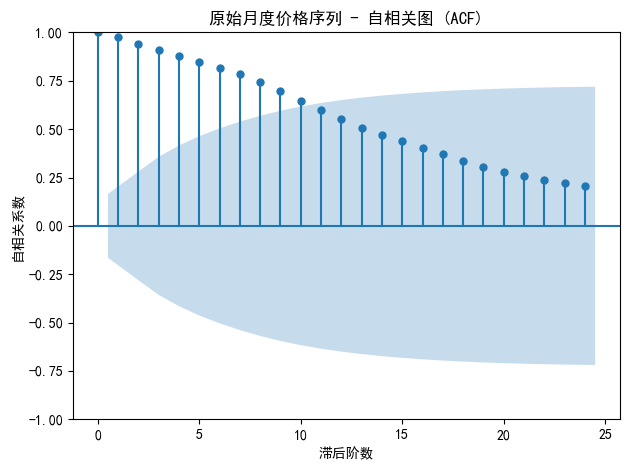

In [2]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ========================  原始序列的时序图 ========================
plt.figure(figsize=(12, 5))
plt.plot(df_month.index, df_month['Price'], color='blue')
plt.title('原始月度价格序列 - 时序图')
plt.xlabel('日期')
plt.ylabel('价格（美元）')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========================  原始序列的自相关图 ========================
plt.figure(figsize=(12, 5))
plot_acf(df_month['Price'].dropna(), lags=24, alpha=0.05)
plt.title('原始月度价格序列 - 自相关图 (ACF)')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.tight_layout()
plt.show()

# 2. 平稳性检验 (ADF) 

In [3]:
def check_stationarity(series, series_name):
    result = adfuller(series.dropna())
    print(f"\n{series_name} 的 ADF 检验结果：")
    print(f"  ADF 统计量: {result[0]:.6f}")
    print(f"  p 值: {result[1]:.6f}")
    print(f"  临界值: 1%={result[4]['1%']:.4f}, 5%={result[4]['5%']:.4f}, 10%={result[4]['10%']:.4f}")
    if result[1] <= 0.05:
        print(f"  结论：序列平稳（拒绝单位根）")
        return True, 0
    else:
        print(f"  结论：序列不平稳，需要差分")
        return False, 1

# 检验原始月度价格
is_stationary, d = check_stationarity(df_month['Price'], "原始月度价格")

# 若不平穩，进行差分
if d == 1:
    df_month['Price_diff'] = df_month['Price'].diff()
    is_stationary_diff, _ = check_stationarity(df_month['Price_diff'], "一阶差分后序列")
    if not is_stationary_diff:
        print("警告：一阶差分后仍不平稳，考虑二阶差分或对数变换")
        d = 2
        df_month['Price_diff2'] = df_month['Price'].diff().diff()
    else:
        print("一阶差分后序列平稳，将使用 d=1")
else:
    df_month['Price_diff'] = df_month['Price']
    
    



原始月度价格 的 ADF 检验结果：
  ADF 统计量: -1.031650
  p 值: 0.741546
  临界值: 1%=-3.4817, 5%=-2.8840, 10%=-2.5788
  结论：序列不平稳，需要差分

一阶差分后序列 的 ADF 检验结果：
  ADF 统计量: -2.930814
  p 值: 0.041880
  临界值: 1%=-3.4817, 5%=-2.8840, 10%=-2.5788
  结论：序列平稳（拒绝单位根）
一阶差分后序列平稳，将使用 d=1


# 一介差分后图检验 

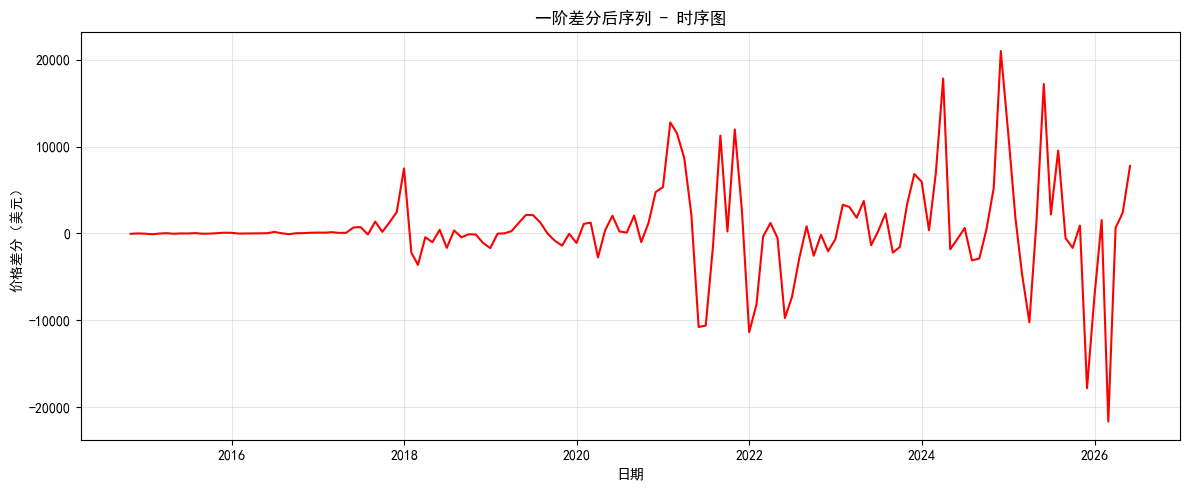

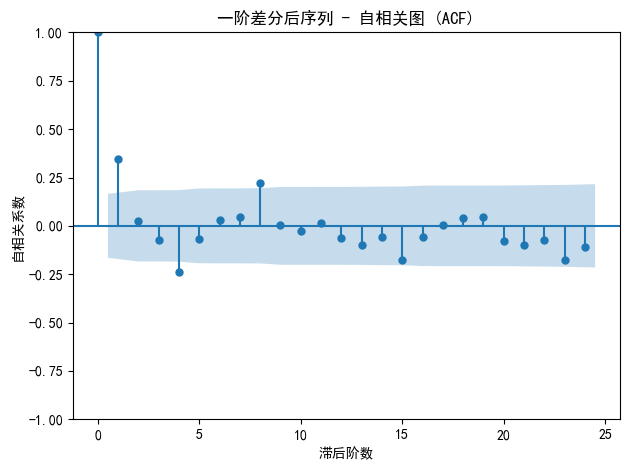

In [4]:
# ======================== 一阶差分 ========================
df_month['Price_diff'] = df_month['Price'].diff()
diff_series = df_month['Price_diff'].dropna()

# ======================== 差分后序列的时序图 ========================
plt.figure(figsize=(12, 5))
plt.plot(diff_series.index, diff_series, color='red')
plt.title('一阶差分后序列 - 时序图')
plt.xlabel('日期')
plt.ylabel('价格差分（美元）')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ======================== 差分后序列的自相关图 ========================
plot_acf(diff_series, lags=24, alpha=0.05)
plt.title('一阶差分后序列 - 自相关图 (ACF)')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.tight_layout()
plt.show()


# 3. 白噪声检验 (Ljung-Box) 

In [5]:
# 对平稳序列（差分后）进行白噪声检验
series_for_model = df_month['Price_diff'].dropna()
lb_test = acorr_ljungbox(series_for_model, lags=12, return_df=True)
print("\n白噪声检验 (Ljung-Box) 结果：")
print(lb_test)
if (lb_test['lb_pvalue'] < 0.05).any():
    print("结论：序列存在自相关，非白噪声，适合 ARMA 建模")
else:
    print("警告：序列接近白噪声，ARMA 模型可能无效")




白噪声检验 (Ljung-Box) 结果：
      lb_stat  lb_pvalue
1   16.939921   0.000039
2   17.046048   0.000199
3   17.831194   0.000477
4   26.125886   0.000030
5   26.755754   0.000064
6   26.870989   0.000153
7   27.205639   0.000306
8   34.768688   0.000029
9   34.775355   0.000065
10  34.887579   0.000131
11  34.925608   0.000255
12  35.552363   0.000382
结论：序列存在自相关，非白噪声，适合 ARMA 建模


# 4. 最优 ARIMA(p,d,q) 模型选择（AIC准则） 

In [6]:
ps = range(0, 4)
qs = range(0, 4)
best_aic = float('inf')
best_order = None
best_model = None
results = []

print("\n开始网格搜索最优 ARIMA(p,d,q)...")
for p, q in product(ps, qs):
    try:
        model = ARIMA(df_month['Price'], order=(p, d, q)).fit()
        aic = model.aic
        results.append(((p, d, q), aic))
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
            best_model = model
    except Exception as e:
        continue

print("\n模型选择结果（AIC）：")
for order, aic in results:
    print(f"ARIMA{order} : AIC = {aic:.2f}")
print(f"\n最优模型: ARIMA{best_order} , AIC = {best_aic:.2f}")
print(best_model.summary())



开始网格搜索最优 ARIMA(p,d,q)...

模型选择结果（AIC）：
ARIMA(0, 1, 0) : AIC = 2803.01
ARIMA(0, 1, 1) : AIC = 2784.86
ARIMA(0, 1, 2) : AIC = 2786.97
ARIMA(0, 1, 3) : AIC = 2787.70
ARIMA(1, 1, 0) : AIC = 2786.37
ARIMA(1, 1, 1) : AIC = 2786.82
ARIMA(1, 1, 2) : AIC = 2788.97
ARIMA(1, 1, 3) : AIC = 2788.80
ARIMA(2, 1, 0) : AIC = 2787.00
ARIMA(2, 1, 1) : AIC = 2787.70
ARIMA(2, 1, 2) : AIC = 2789.98
ARIMA(2, 1, 3) : AIC = 2780.22
ARIMA(3, 1, 0) : AIC = 2788.68
ARIMA(3, 1, 1) : AIC = 2789.45
ARIMA(3, 1, 2) : AIC = 2791.39
ARIMA(3, 1, 3) : AIC = 2787.26

最优模型: ARIMA(2, 1, 3) , AIC = 2780.22
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  141
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -1384.110
Date:                Wed, 17 Jun 2026   AIC                           2780.219
Time:                        19:23:37   BIC                           2797.869
Sample:                    09-3

#  5. 模型诊断 

In [7]:

resid = best_model.resid

# ---------- 步骤1：模型的显著性检验（残差白噪声检验） ----------
print("\n" + "="*60)
print("步骤1：模型的显著性检验（残差白噪声检验）")
print("="*60)
lb_resid = acorr_ljungbox(resid, lags=10, return_df=True)
print(lb_resid)

# 判断是否通过白噪声检验
if (lb_resid['lb_pvalue'] > 0.05).all():
    print("\n✅ 结论：残差序列为白噪声（所有滞后阶数 p > 0.05）")
    print("   模型已充分提取自相关信息，模型整体显著有效。")
    model_valid = True
else:
    print("\n❌ 结论：残差序列不是白噪声（存在 p ≤ 0.05 的滞后阶数）")
    print("   模型仍有未提取的自相关，需要重新定阶或增加参数。")
    model_valid = False
    # 注意：如果模型无效，后续的参数显著性检验意义不大，但仍可输出供参考

# ---------- 步骤2：参数的显著性检验 ----------
print("\n" + "="*60)
print("步骤2：参数的显著性检验")
print("="*60)

# 从 best_model 中提取参数表
params_table = best_model.summary().tables[1]
print(params_table)

# 获取参数 p 值（从模型结果中提取）
pvalues = best_model.pvalues
print("\n各参数 p 值：")
for name, pv in pvalues.items():
    print(f"  {name}: {pv:.6f}")

# 判断每个参数是否显著
insignificant = [name for name, pv in pvalues.items() if pv >= 0.05]
if insignificant:
    print(f"\n⚠️ 以下参数不显著（p ≥ 0.05）：{insignificant}")
    print("   建议剔除不显著参数，重新拟合模型。")
else:
    print("\n✅ 所有参数均在 0.05 水平上显著非零。")

# ---------- 步骤3：其他诊断（正态性、异方差） ----------
print("\n" + "="*60)
print("步骤3：其他诊断（正态性、异方差）")
print("="*60)
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(resid)
print(f"Jarque-Bera 检验：统计量={jb_stat:.2f}, p值={jb_p:.4f}")
if jb_p < 0.05:
    print("  残差不服从正态分布（存在尖峰厚尾）")

from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(resid)
print(f"ARCH 异方差检验：LM统计量={arch_test[0]:.2f}, p值={arch_test[1]:.4f}")
if arch_test[1] < 0.05:
    print("  残差存在条件异方差（波动率集聚）")



步骤1：模型的显著性检验（残差白噪声检验）
      lb_stat  lb_pvalue
1    0.582848   0.445198
2    0.703317   0.703520
3    3.125277   0.372710
4    4.666765   0.323229
5    7.032369   0.218244
6    7.736036   0.258087
7    7.923696   0.339370
8   14.876068   0.061601
9   15.268421   0.083822
10  15.324575   0.120669

✅ 结论：残差序列为白噪声（所有滞后阶数 p > 0.05）
   模型已充分提取自相关信息，模型整体显著有效。

步骤2：参数的显著性检验
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2723      0.062    -20.445      0.000      -1.394      -1.150
ar.L2         -0.9450      0.068    -13.846      0.000      -1.079      -0.811
ma.L1          1.6932      0.088     19.350      0.000       1.522       1.865
ma.L2          1.5024      0.131     11.464      0.000       1.246       1.759
ma.L3          0.4922      0.078      6.346      0.000       0.340       0.644
sigma2      2.689e+07   1.47e-09   1.82e+16      0.000    2.69e+07    2.69e+0

#  6. 预测未来8个月 

In [8]:
last_date = df_month.index[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=8, freq='M')
forecast = best_model.forecast(steps=8)
forecast_series = pd.Series(forecast, index=future_dates, name='Forecast')

print("\n未来8个月预测结果：")
pred_df = pd.DataFrame({'预测日期': future_dates.strftime('%Y-%m-%d'), '预测价格(美元)': forecast.values})
print(pred_df.to_string(index=False))



未来8个月预测结果：
      预测日期     预测价格(美元)
2026-06-30 90234.557600
2026-07-31 86840.871127
2026-08-31 86760.655764
2026-09-30 90069.836673
2026-10-31 85935.310485
2026-11-30 88068.482770
2026-12-31 89261.642513
2027-01-31 85727.660470


# 7. 绘图 

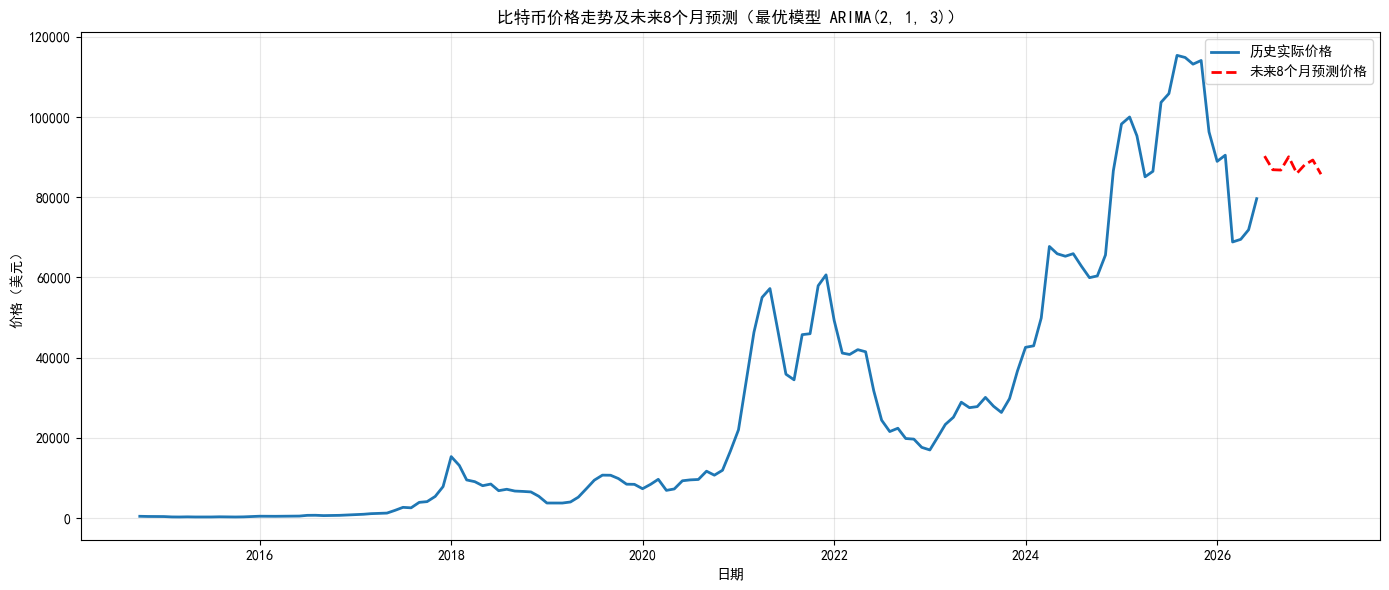

In [9]:

plt.figure(figsize=(14, 6))
plt.plot(df_month.index, df_month['Price'], label='历史实际价格', linewidth=2)
plt.plot(forecast_series.index, forecast_series, 'r--', label='未来8个月预测价格', linewidth=2)
plt.title(f'比特币价格走势及未来8个月预测（最优模型 ARIMA{best_order}）')
plt.xlabel('日期')
plt.ylabel('价格（美元）')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()